# Ejercicio Guiado: Optimizando la Cadena de Suministro
## Celda 1: Datos de la Cadena de Suministro
Definimos el mapa de rutas con sus costos reales (g) y las estimaciones de distancia (h).

In [10]:
# Celda 1: Variables Globales (Rutas y Heurística)

# Grafo con costos reales de viaje (g)
rutas_suministro = {
  'Fabrica': {'Ciudad A': 2, 'Pueblo B': 4},
  'Ciudad A': {'Ciudad C': 7},
  'Pueblo B': {'Ciudad C': 3},
  'Ciudad C': {'Destino': 5},
  'Destino': {}
}
                        
# Distancia estimada al Destino (h)
heuristica_distancia = {
  'Fabrica': 10, 'Ciudad A': 5,
  'Pueblo B': 8, 'Ciudad C': 4,
  'Destino': 0
}

# Celda 2: Algoritmos de Planificación
## Mantenemos las mismas funciones para que puedas ver cómo el mismo código resuelve un problema diferente.

In [11]:
# Celda 2: Funciones de Búsqueda
import heapq

# --- Implementación de Búsqueda Voraz Primero el Mejor ---
def greedy_best_first(graph, start, goal, heuristics):
    priority_queue = [(heuristics[start], [start])]
    visited = set()
    while priority_queue:
        _, path = heapq.heappop(priority_queue)
        node = path[-1]
        if node in visited: continue
        visited.add(node)
        if node == goal: return path
        for neighbor in graph[node]:
            if neighbor not in visited:
                heapq.heappush(priority_queue, (heuristics[neighbor], path + [neighbor]))
    return None

# --- Implementación de Búsqueda A* (A-Estrella) ---
def a_star_search(graph, start, goal, heuristics):
    priority_queue = [(0 + heuristics[start], 0, [start])]
    visited = set()
    while priority_queue:
        f, g, path = heapq.heappop(priority_queue)
        node = path[-1]
        if node in visited: continue
        visited.add(node)
        if node == goal: return path, g
        for neighbor, cost in graph[node].items():
            if neighbor not in visited:
                new_g = g + cost
                new_f = new_g + heuristics[neighbor]
                heapq.heappush(priority_queue, (new_f, new_g, path + [neighbor]))
    return None, -1

# Celda 3: Ejecución de las Rutas
## Comprobamos los resultados de ambos métodos logísticos.

In [12]:
# Celda 3: Pruebas de los algoritmos
print("📦 --- Iniciando Planificación de Rutas --- 📦\n")

# Ejecutar Greedy Best-First
ruta_greedy = greedy_best_first(rutas_suministro, 'Fabrica', 'Destino', heuristica_distancia)
print(f"Ruta Voraz (Greedy): \nCamino tomado: {ruta_greedy}\n")

# Ejecutar A*
ruta_astar, costo_astar = a_star_search(rutas_suministro, 'Fabrica', 'Destino', heuristica_distancia)
print(f"Ruta Óptima (A*): \nCamino tomado: {ruta_astar} \nCosto total del envío: {costo_astar} unidades monetarias")

📦 --- Iniciando Planificación de Rutas --- 📦

Ruta Voraz (Greedy): 
Camino tomado: ['Fabrica', 'Ciudad A', 'Ciudad C', 'Destino']

Ruta Óptima (A*): 
Camino tomado: ['Fabrica', 'Pueblo B', 'Ciudad C', 'Destino'] 
Costo total del envío: 12 unidades monetarias


# Celda 4: Visualización del Grafo Logístico
## Este código ajusta las posiciones para adaptarse a la estructura de tu nuevo problema (una forma de diamante).

/tmp/ipykernel_32816/1196201070.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


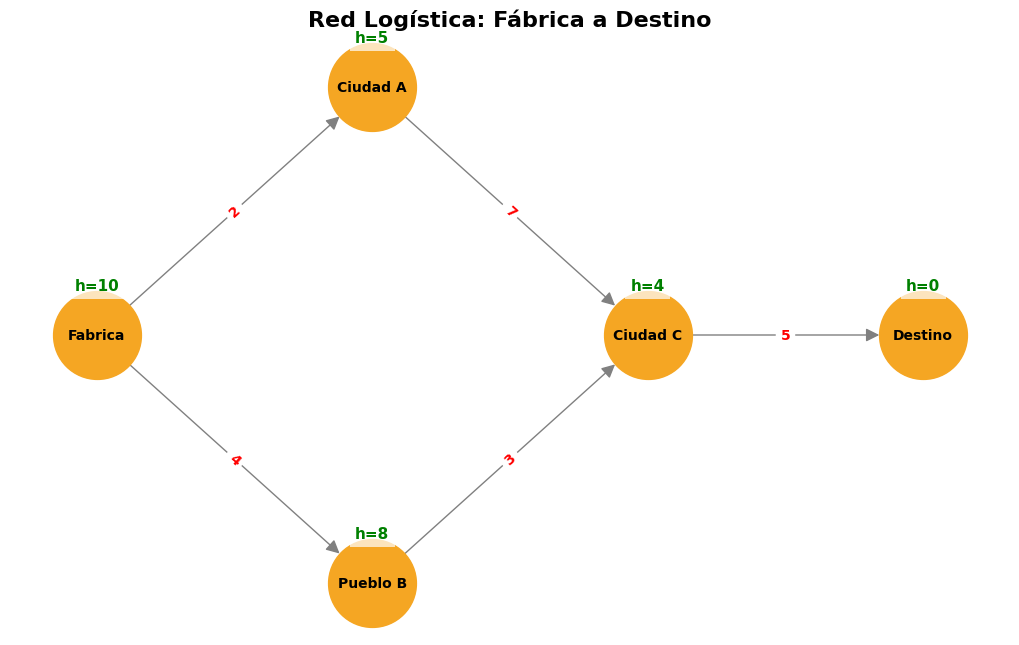

In [14]:
# Celda 4: Gráfica de la red de suministro
import networkx as nx
import matplotlib.pyplot as plt

# Crear un grafo dirigido
G = nx.DiGraph()

# Poblar el grafo
for origen, destinos in rutas_suministro.items():
    for destino, costo in destinos.items():
        G.add_edge(origen, destino, weight=costo)

# Configurar el lienzo
plt.figure(figsize=(10, 6))

# Definir coordenadas manuales (forma de diamante)
posiciones = {
    'Fabrica': (0, 0),
    'Ciudad A': (1, 1),
    'Pueblo B': (1, -1),
    'Ciudad C': (2, 0),
    'Destino': (3, 0)
}

# Dibujar los nodos
nx.draw(G, posiciones, with_labels=True, node_color='#F5A623', 
        node_size=4000, font_size=10, font_weight='bold', 
        font_color='black', edge_color='gray', arrows=True, arrowsize=20)

# Dibujar las etiquetas de costo (g) en rojo
etiquetas_aristas = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, posiciones, edge_labels=etiquetas_aristas, font_color='red', font_weight='bold')

# Añadir la heurística (h) en verde
for nodo, (x, y) in posiciones.items():
    plt.text(x, y + 0.18, f"h={heuristica_distancia[nodo]}", fontsize=11, color='green', 
             fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.title("Red Logística: Fábrica a Destino", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()